C:\Users\GLI\AppData\Local\Temp\ipykernel_4168\3868605404.py:28: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img))
C:\Users\GLI\AppData\Local\Temp\ipykernel_4168\3868605404.py:28: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img))
C:\Users\GLI\AppData\Local\Temp\ipykernel_4168\3868605404.py:29: RuntimeWarning: divide by zero encountered in log
  log_trans = c * np.log(1 + img)
C:\Users\GLI\AppData\Local\Temp\ipykernel_4168\3868605404.py:29: RuntimeWarning: invalid value encountered in multiply
  log_trans = c * np.log(1 + img)
C:\Users\GLI\AppData\Local\Temp\ipykernel_4168\3868605404.py:30: RuntimeWarning: invalid value encountered in cast
  log_trans = np.array(log_trans, dtype=np.uint8)


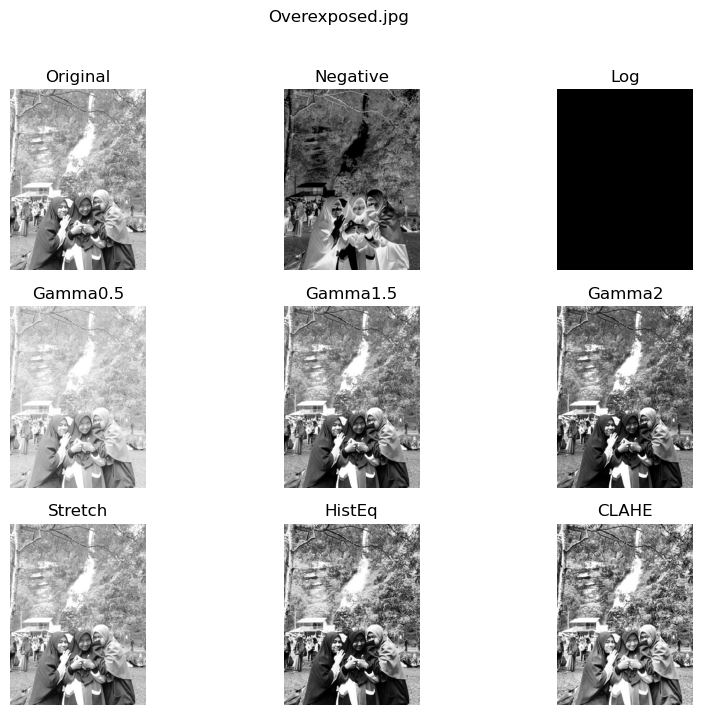

C:\Users\GLI\AppData\Local\Temp\ipykernel_4168\3868605404.py:82: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.ravel(),256,[0,256])
C:\Users\GLI\AppData\Local\Temp\ipykernel_4168\3868605404.py:86: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(clahe_img.ravel(),256,[0,256])


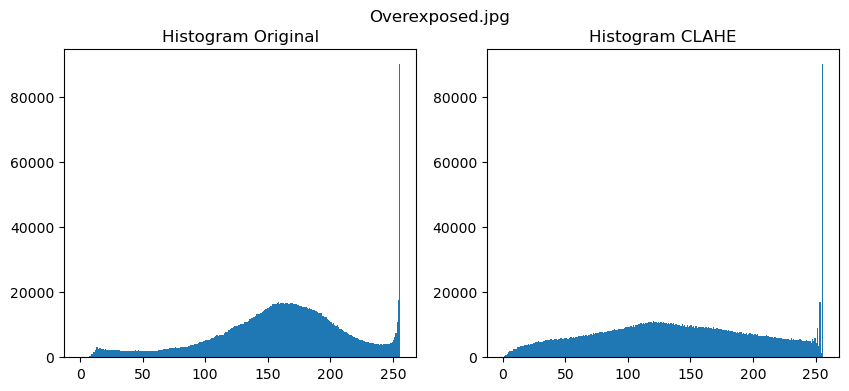

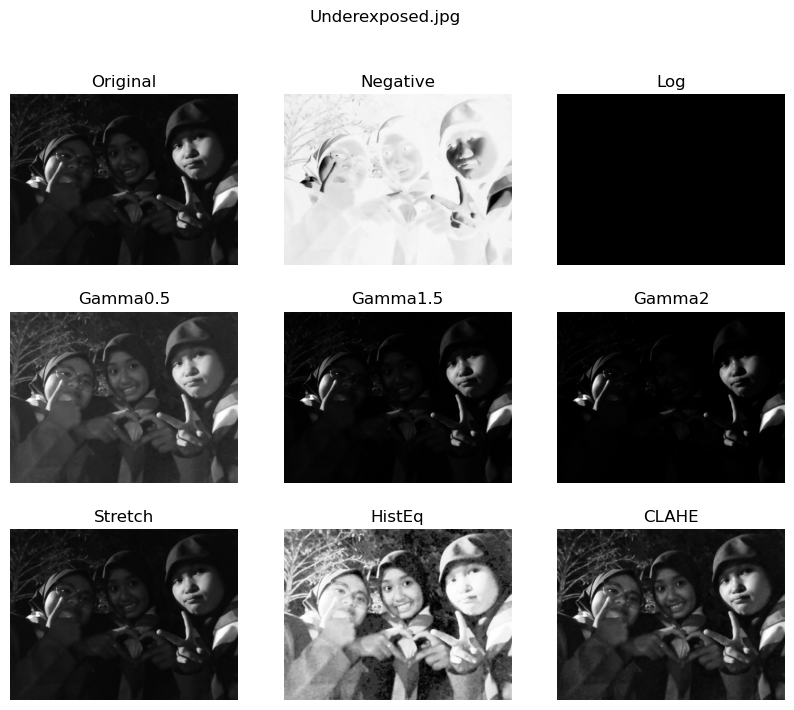

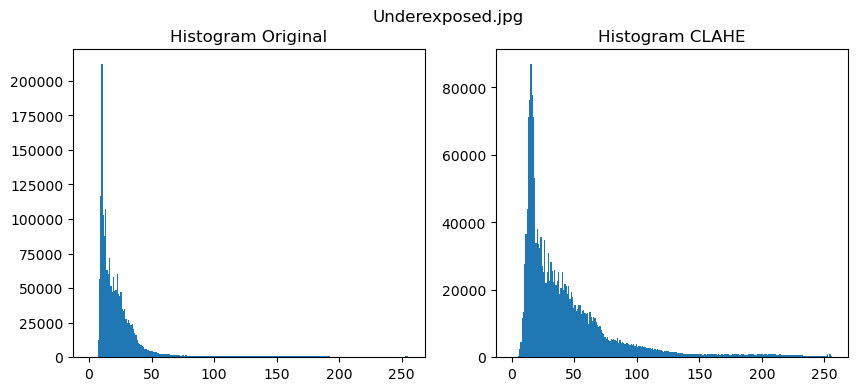

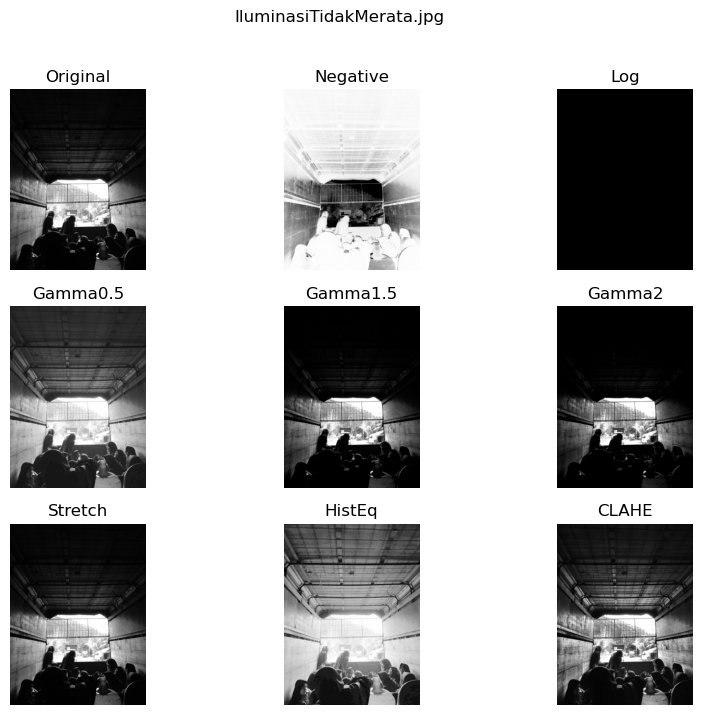

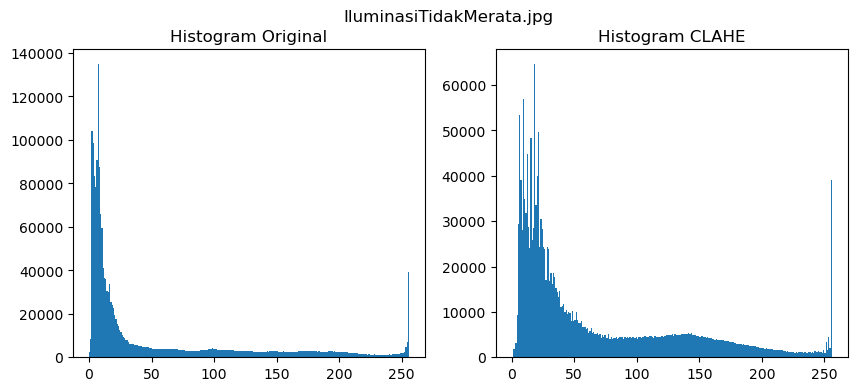

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# folder tempat menyimpan gambar
folder_path = "images"

# membaca semua file gambar dalam folder
files = os.listdir(folder_path)

for file in files:
    
    path = os.path.join(folder_path, file)
    img = cv2.imread(path, 0)  # grayscale
    
    if img is None:
        continue

    # ======================
    # POINT PROCESSING
    # ======================

    # Negative
    negative = 255 - img

    # Log Transformation
    c = 255 / np.log(1 + np.max(img))
    log_trans = c * np.log(1 + img)
    log_trans = np.array(log_trans, dtype=np.uint8)

    # Gamma correction
    gamma05 = np.array(255 * (img / 255) ** 0.5, dtype='uint8')
    gamma15 = np.array(255 * (img / 255) ** 1.5, dtype='uint8')
    gamma20 = np.array(255 * (img / 255) ** 2.0, dtype='uint8')

    # ======================
    # HISTOGRAM ENHANCEMENT
    # ======================

    # Contrast stretching
    min_val = np.min(img)
    max_val = np.max(img)
    stretch = (img - min_val) / (max_val - min_val) * 255
    stretch = np.array(stretch, dtype=np.uint8)

    # Histogram Equalization
    hist_eq = cv2.equalizeHist(img)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahe_img = clahe.apply(img)

    # ======================
    # TAMPILKAN HASIL
    # ======================

    titles = ['Original','Negative','Log','Gamma0.5','Gamma1.5','Gamma2',
              'Stretch','HistEq','CLAHE']

    images = [img, negative, log_trans, gamma05, gamma15,
              gamma20, stretch, hist_eq, clahe_img]

    plt.figure(figsize=(10,8))

    for i in range(len(images)):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

    plt.suptitle(file)
    plt.show()

    # ======================
    # HISTOGRAM SEBELUM & SESUDAH
    # ======================

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(img.ravel(),256,[0,256])
    plt.title("Histogram Original")

    plt.subplot(1,2,2)
    plt.hist(clahe_img.ravel(),256,[0,256])
    plt.title("Histogram CLAHE")

    plt.suptitle(file)
    plt.show()